Loaded reference:
  x shape = (513,)
  t shape = (201,)
  u_ref shape = (201, 513)
  u_ref min/max = -1.0 0.9918149256349341

Parameter counts:
  Sto-SQP theta size = 1981
  Det-SQP theta size = 1981
  ALM theta size     = 1981
  Adam theta size    = 7851

Full-grid metrics:
Sto-SQP              MSE = 4.296415e-06   relL2 = 2.935224e-03
Deterministic SQP    MSE = 3.537522e-05   relL2 = 8.422435e-03
ALM                  MSE = 2.773161e-04   relL2 = 2.358173e-02
Adam                 MSE = 3.719621e-01   relL2 = 8.636494e-01

Error color scale:
  vmin = 1e-08
  vmax = 1.9516926140420496

Saved figure -> allen_cahn_reference_plus_4_errors.png
Saved figure -> allen_cahn_reference_plus_4_errors.pdf


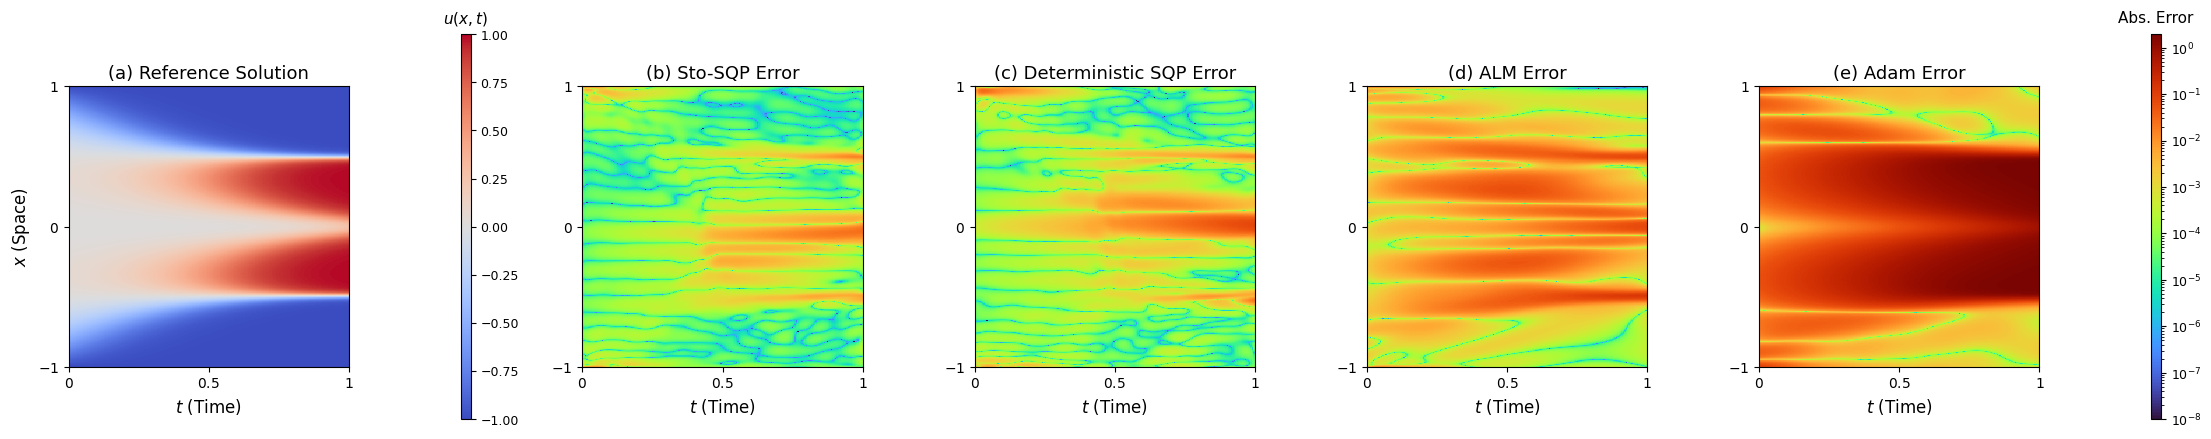

In [5]:
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ============================================================
# USER SETTINGS
# ============================================================

REF_PATH = "../1/allen_cahn_python.mat"

DET_SQP_PATH = "../1/allen_cahn_stosqp_final_1.npy"
STO_SQP_PATH = "../1/allen_cahn_stosqp_final_deter.npy"
ALM_PATH     = "../1/traditional_alm_allen_cahn_best.npy"
ADAM_PATH    = "../allen_cahn_adam_best_theta.npy"

SAVE_PREFIX = "allen_cahn_reference_plus_4_errors"

X_MIN, X_MAX = -1.0, 1.0
T_MIN, T_MAX =  0.0, 1.0

SQP_LAYER_SIZES  = [2, 30, 30, 30, 1]
ALM_LAYER_SIZES  = [2, 30, 30, 30, 1]
ADAM_LAYER_SIZES = [2, 50, 50, 50, 50, 1]

SQP_ACTIVATION  = "tanh"
ALM_ACTIVATION  = "tanh"
ADAM_ACTIVATION = "tanh"

NORMALIZE_INPUT = True

ERR_FLOOR = 1e-8
FIG_DPI = 300


# ============================================================
# HELPERS
# ============================================================

def check_file(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return path


def load_reference_mat(path):
    mat = scipy.io.loadmat(path)

    if "x" not in mat or "t" not in mat or "usol" not in mat:
        raise KeyError("Reference .mat must contain keys: x, t, usol")

    x = np.asarray(mat["x"]).squeeze().astype(np.float64)
    t = np.asarray(mat["t"]).squeeze().astype(np.float64)
    u_ref = np.asarray(mat["usol"]).astype(np.float64)

    if u_ref.shape[0] != len(t) and u_ref.shape[1] == len(t):
        u_ref = u_ref.T

    if u_ref.shape != (len(t), len(x)):
        raise ValueError(
            f"Reference usol shape mismatch. "
            f"Expected {(len(t), len(x))}, got {u_ref.shape}"
        )

    return x, t, u_ref


def normalize_xt(X):
    x = X[:, 0:1]
    t = X[:, 1:2]

    x_n = 2.0 * (x - X_MIN) / (X_MAX - X_MIN) - 1.0
    t_n = 2.0 * (t - T_MIN) / (T_MAX - T_MIN) - 1.0

    return np.concatenate([x_n, t_n], axis=1)


def activate(z, name):
    if name == "tanh":
        return np.tanh(z)
    elif name == "silu":
        return z / (1.0 + np.exp(-z))
    elif name == "gelu":
        return 0.5 * z * (
            1.0 + np.tanh(np.sqrt(2.0 / np.pi) * (z + 0.044715 * z ** 3))
        )
    else:
        raise ValueError(f"Unsupported activation: {name}")


def unflatten_theta(theta, layer_sizes):
    theta = np.asarray(theta, dtype=np.float64).reshape(-1)
    params = []
    idx = 0

    for m, n in zip(layer_sizes[:-1], layer_sizes[1:]):
        w_size = m * n
        b_size = n

        W = theta[idx:idx + w_size].reshape(m, n)
        idx += w_size

        b = theta[idx:idx + b_size].reshape(1, n)
        idx += b_size

        params.append((W, b))

    if idx != len(theta):
        raise ValueError(
            f"Did not consume all theta entries: used {idx}, total {len(theta)}.\n"
            f"Layer sizes = {layer_sizes}"
        )

    return params


def mlp_predict(theta, layer_sizes, X, activation="tanh", normalize_input=True):
    params = unflatten_theta(theta, layer_sizes)

    H = normalize_xt(X) if normalize_input else X.copy()

    for i, (W, b) in enumerate(params):
        H = H @ W + b
        if i < len(params) - 1:
            H = activate(H, activation)

    return H[:, 0]


def predict_on_grid(theta, layer_sizes, x, t, activation="tanh", normalize_input=True):
    XX, TT = np.meshgrid(x, t, indexing="xy")

    X_eval = np.stack(
        [XX.reshape(-1), TT.reshape(-1)],
        axis=1,
    )

    u_pred = mlp_predict(
        theta=theta,
        layer_sizes=layer_sizes,
        X=X_eval,
        activation=activation,
        normalize_input=normalize_input,
    )

    return u_pred.reshape(len(t), len(x))


def mse(a, b):
    return float(np.mean((a - b) ** 2))


def rel_l2(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2) / (np.mean(b ** 2) + 1e-30)))


# ============================================================
# MAIN
# ============================================================

def main():
    check_file(REF_PATH)
    check_file(STO_SQP_PATH)
    check_file(DET_SQP_PATH)
    check_file(ALM_PATH)
    check_file(ADAM_PATH)

    x, t, u_ref = load_reference_mat(REF_PATH)

    print("Loaded reference:")
    print("  x shape =", x.shape)
    print("  t shape =", t.shape)
    print("  u_ref shape =", u_ref.shape)
    print("  u_ref min/max =", np.min(u_ref), np.max(u_ref))

    theta_sto  = np.asarray(np.load(STO_SQP_PATH, allow_pickle=True), dtype=np.float64).reshape(-1)
    theta_det  = np.asarray(np.load(DET_SQP_PATH, allow_pickle=True), dtype=np.float64).reshape(-1)
    theta_alm  = np.asarray(np.load(ALM_PATH, allow_pickle=True), dtype=np.float64).reshape(-1)
    theta_adam = np.asarray(np.load(ADAM_PATH, allow_pickle=True), dtype=np.float64).reshape(-1)

    print("\nParameter counts:")
    print("  Sto-SQP theta size =", theta_sto.size)
    print("  Det-SQP theta size =", theta_det.size)
    print("  ALM theta size     =", theta_alm.size)
    print("  Adam theta size    =", theta_adam.size)

    u_sto = predict_on_grid(
        theta_sto, SQP_LAYER_SIZES, x, t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_det = predict_on_grid(
        theta_det, SQP_LAYER_SIZES, x, t,
        activation=SQP_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_alm = predict_on_grid(
        theta_alm, ALM_LAYER_SIZES, x, t,
        activation=ALM_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    u_adam = predict_on_grid(
        theta_adam, ADAM_LAYER_SIZES, x, t,
        activation=ADAM_ACTIVATION,
        normalize_input=NORMALIZE_INPUT,
    )

    err_sto  = np.abs(u_sto  - u_ref)
    err_det  = np.abs(u_det  - u_ref)
    err_alm  = np.abs(u_alm  - u_ref)
    err_adam = np.abs(u_adam - u_ref)

    print("\nFull-grid metrics:")
    for name, upred in [
        ("Sto-SQP", u_sto),
        ("Deterministic SQP", u_det),
        ("ALM", u_alm),
        ("Adam", u_adam),
    ]:
        print(
            f"{name:<20s} MSE = {mse(upred, u_ref):.6e}   "
            f"relL2 = {rel_l2(upred, u_ref):.6e}"
        )

    # --------------------------------------------------------
    # Color setup
    # --------------------------------------------------------
    ref_cmap = "coolwarm"
    err_cmap = "turbo"

    vabs_ref = np.max(np.abs(u_ref))
    ref_vmin = -vabs_ref
    ref_vmax =  vabs_ref

    all_err = np.concatenate([
        err_sto.ravel(),
        err_det.ravel(),
        err_alm.ravel(),
        err_adam.ravel(),
    ])

    err_vmax = max(float(np.max(all_err)), ERR_FLOOR * 10.0)

    print("\nError color scale:")
    print("  vmin =", ERR_FLOOR)
    print("  vmax =", err_vmax)

    err_sto_plot  = np.maximum(err_sto,  ERR_FLOOR)
    err_det_plot  = np.maximum(err_det,  ERR_FLOOR)
    err_alm_plot  = np.maximum(err_alm,  ERR_FLOOR)
    err_adam_plot = np.maximum(err_adam, ERR_FLOOR)

    err_norm = LogNorm(vmin=ERR_FLOOR, vmax=err_vmax)
    extent = [t[0], t[-1], x[0], x[-1]]

    # --------------------------------------------------------
    # Figure layout
    # --------------------------------------------------------
    fig = plt.figure(figsize=(27, 5.0))

    gs = fig.add_gridspec(
        1,
        7,
        width_ratios=[1.0, 0.035, 1.0, 1.0, 1.0, 1.0, 0.035],
        wspace=0.55,
    )

    ax_ref  = fig.add_subplot(gs[0, 0])
    cax_ref = fig.add_subplot(gs[0, 1])

    ax_sto  = fig.add_subplot(gs[0, 2])
    ax_det  = fig.add_subplot(gs[0, 3])
    ax_alm  = fig.add_subplot(gs[0, 4])
    ax_adam = fig.add_subplot(gs[0, 5])

    cax_err = fig.add_subplot(gs[0, 6])

    im_ref = ax_ref.imshow(
        u_ref.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=ref_cmap,
        vmin=ref_vmin,
        vmax=ref_vmax,
        interpolation="nearest",
    )

    cb_ref = fig.colorbar(im_ref, cax=cax_ref)
    cb_ref.ax.set_title(r"$u(x,t)$", fontsize=11, pad=8)
    cb_ref.ax.tick_params(labelsize=9)

    ax_ref.set_title("(a) Reference Solution", fontsize=13)

    im_sto = ax_sto.imshow(
        err_sto_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=err_cmap,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_sto.set_title("(b) Sto-SQP Error", fontsize=13)

    im_det = ax_det.imshow(
        err_det_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=err_cmap,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_det.set_title("(c) Deterministic SQP Error", fontsize=13)

    im_alm = ax_alm.imshow(
        err_alm_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=err_cmap,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_alm.set_title("(d) ALM Error", fontsize=13)

    im_adam = ax_adam.imshow(
        err_adam_plot.T,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap=err_cmap,
        norm=err_norm,
        interpolation="nearest",
    )
    ax_adam.set_title("(e) Adam Error", fontsize=13)

    cb_err = fig.colorbar(im_adam, cax=cax_err)
    cb_err.ax.set_title("Abs. Error", fontsize=11, pad=8)
    cb_err.ax.tick_params(labelsize=9)

    # --------------------------------------------------------
    # Axis labels / tick labels
    # --------------------------------------------------------
    all_axes = [ax_ref, ax_sto, ax_det, ax_alm, ax_adam]

    for ax in all_axes:
        ax.set_xlabel(r"$t$ (Time)", fontsize=12)

        ax.set_xlim(float(t[0]), float(t[-1]))
        ax.set_ylim(float(x[0]), float(x[-1]))

        ax.set_xticks([0.0, 0.5, 1.0])
        ax.set_xticklabels([r"$0$", r"$0.5$", r"$1$"])

        ax.set_yticks([-1.0, 0.0, 1.0])
        ax.set_yticklabels([r"$-1$", r"$0$", r"$1$"])

        ax.tick_params(labelsize=10)
        ax.set_box_aspect(1)

    ax_ref.set_ylabel(r"$x$ (Space)", fontsize=12)

    for ax in [ax_sto, ax_det, ax_alm, ax_adam]:
        ax.set_ylabel("")

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------
    fig.savefig(f"{SAVE_PREFIX}.png", dpi=FIG_DPI, bbox_inches="tight")
    fig.savefig(f"{SAVE_PREFIX}.pdf", bbox_inches="tight")

    print(f"\nSaved figure -> {SAVE_PREFIX}.png")
    print(f"Saved figure -> {SAVE_PREFIX}.pdf")

    plt.show()


if __name__ == "__main__":
    main()